# Data Exploration

Exploring the Crop Recommendation dataset before model training.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("../outputs", exist_ok=True)

df = pd.read_csv("../Dataset/Crop_recommendation_dataset.csv")
print(f"Shape: {df.shape}")
print(f"Columns in our dataset: {list(df.columns)}")
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nStatistical summary:")
print(df.describe())

Shape: (2200, 8)
Columns in our dataset: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

First 5 rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0

Statistical summary:
                 N            P  ...           ph     rainfa

## Basic Checks

Before training, we check if the dataset has missing values, repeated rows, or values that do not make sense.

In [2]:
checks = {
    "pH between 0 and 14": df["ph"].between(0, 14).all(),
    "Humidity between 0 and 100": df["humidity"].between(0, 100).all(),
    "No negative N": (df["N"] >= 0).all(),
    "No negative P": (df["P"] >= 0).all(),
    "No negative K": (df["K"] >= 0).all(),
    "No negative rainfall": (df["rainfall"] >= 0).all(),
}
for name, result in checks.items():
    print(f"{name}: {result}")

print("Number of crop classes:", df["label"].nunique())
print("Records per crop:")
print(df["label"].value_counts().sort_index())

pH between 0 and 14: True
Humidity between 0 and 100: True
No negative N: True
No negative P: True
No negative K: True
No negative rainfall: True
Number of crop classes: 22
Records per crop:
label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64


## Crop Distribution

This plot helps us check whether some crops have many more records than others.

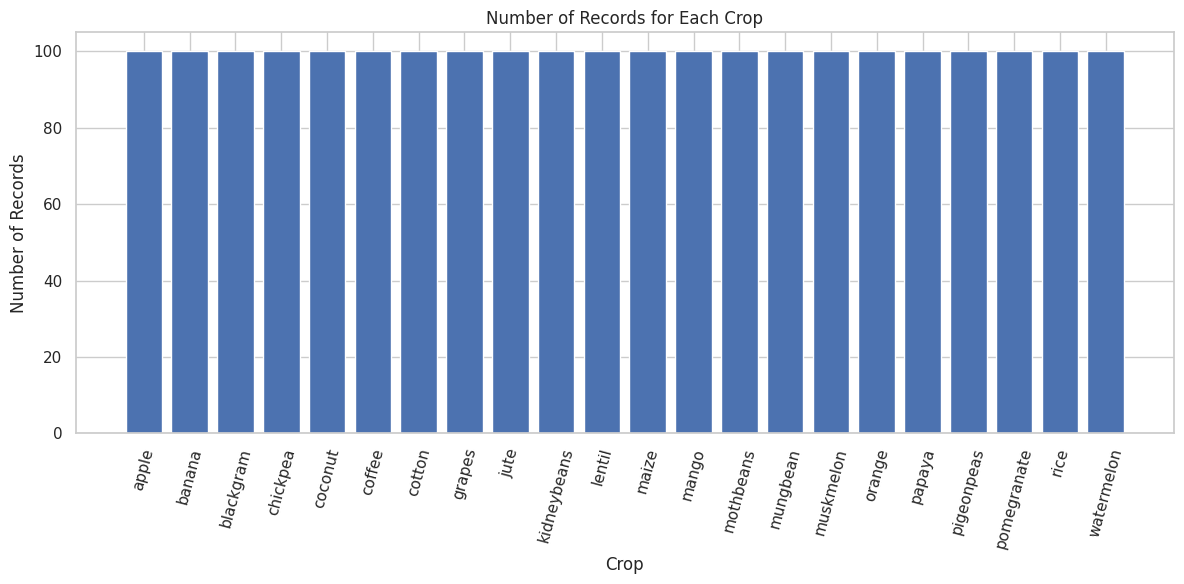

In [3]:
crop_counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(crop_counts.index, crop_counts.values)
plt.title("Number of Records for Each Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig("../outputs/crop_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Feature Distributions

The boxplots show how the seven input features vary across the full dataset. Some values look far from the middle, but this can be normal because different crops need very different growing conditions.

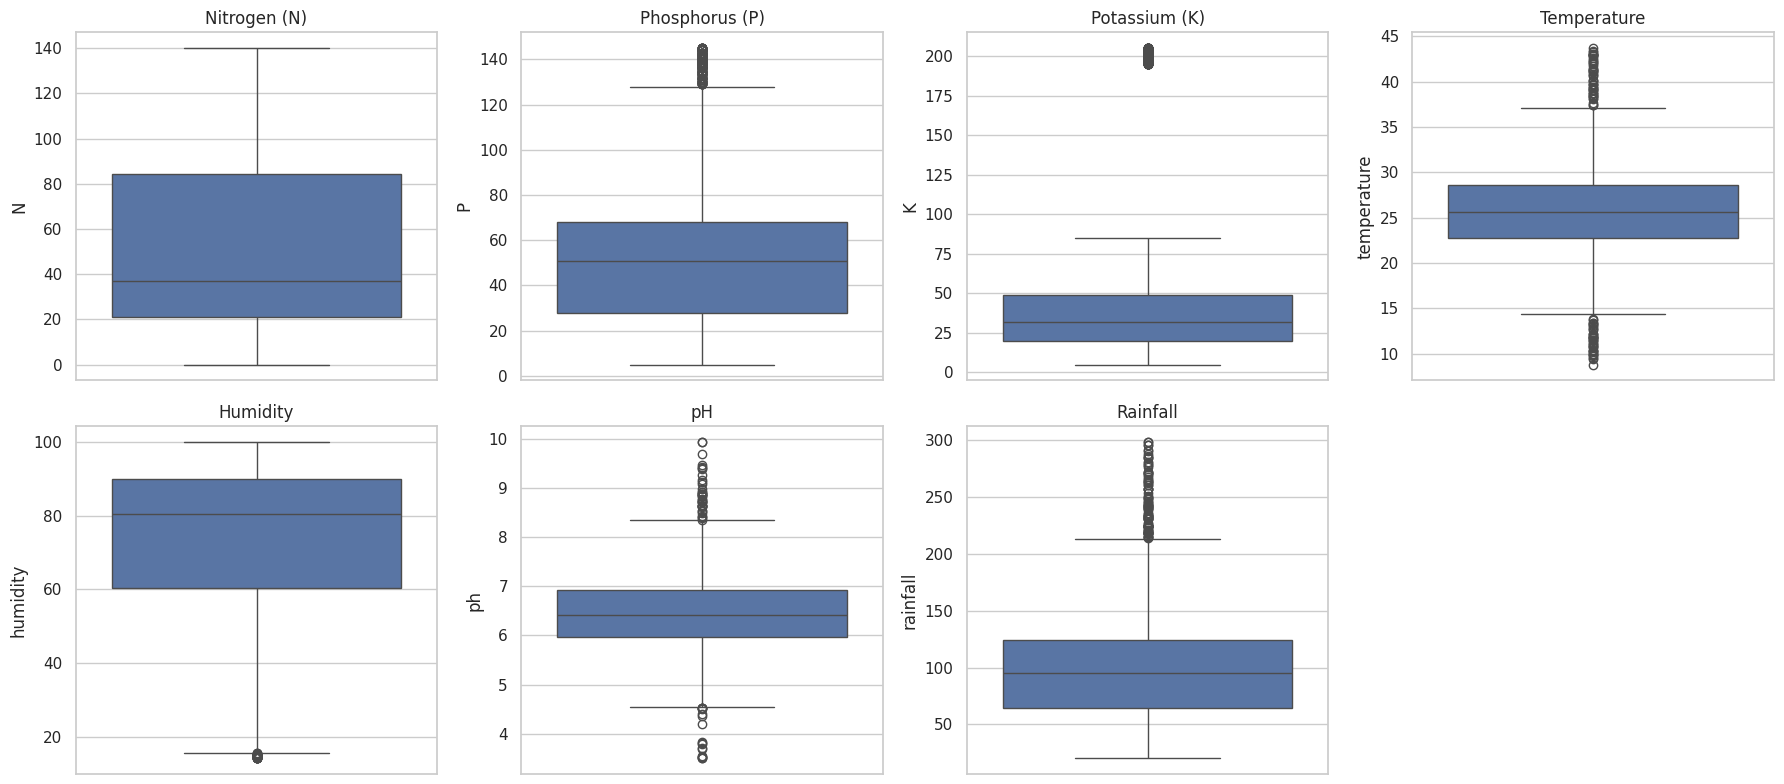

In [4]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
display_names = ["Nitrogen (N)", "Phosphorus (P)", "Potassium (K)", "Temperature", "Humidity", "pH", "Rainfall"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(display_names[i])
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig("../outputs/feature_boxplots.png", dpi=180, bbox_inches="tight")
plt.show()

## Correlation Between Input Features

The correlation heatmap gives us a quick view of how the numeric input features move with each other. It is only for understanding the data; we do not remove a feature just because two variables have some relationship.

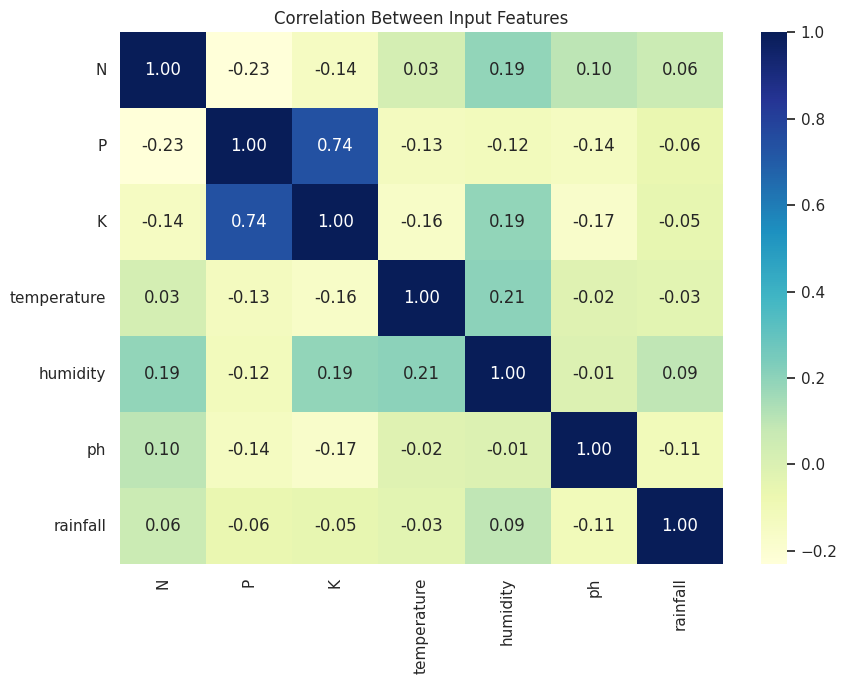

In [5]:
plt.figure(figsize=(9, 7))
corr = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Between Input Features")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

# Findings

The dataset has 2,200 rows and 8 columns. Seven columns are the inputs and `label` is the crop we want to predict. There are 22 crop classes, with 100 records for each crop, so the target classes are balanced.

There are no missing values or duplicate rows. The basic range checks also passed. We kept the full dataset because values that may look unusual across all crops can still be normal for a particular crop.